# Lecture 5 — Line Opacity II: The Line List

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Read a **line list** and say what each column means — wavelength, `log gf`, the species code, the excitation potential, and the three damping constants.
- Build the **logarithmic wavelength grid** a synthesis runs on, and explain the resolving power that sets it.
- Form the **exact lower-level population** the production code uses — the ionic number density divided by the partition function — and the **FASTEX** tabulated Boltzmann factor that completes it.
- **Accumulate** the full atomic line list — every metal from lithium to uranium, plus helium — into a total line-opacity array with the production code's **Voigt wing-accumulation kernel** and its **cutoff**.
- Reproduce the reference atomic line opacity to **machine precision**, and see exactly which physics each input carries.
- Recognize the **non-Voigt line types** the line-type code can route to — the autoionizing (Fano/shore) and merged-continuum profiles — covered as an extension in the final section.

## Introduction

One line was Lecture 4; a spectrum is a forest. The Kurucz atomic line list holds nearly **two million** transitions, each with its own wavelength, strength, and broadening — and the opacity at any wavelength is the sum of the line profiles of every nearby transition. This lecture does the bookkeeping exactly: we read the list, lay down the wavelength grid, build each line's population and Voigt profile the way the production code does, and accumulate them with its own wing kernel and cutoff.

The target is the **atomic** line opacity — every metal line in the window, lithium through uranium, plus the helium lines. Hydrogen is held back: its Balmer wings are dominated by Stark broadening from the plasma microfields of charged perturbers — possible because hydrogen's near-degenerate levels respond *linearly* to an electric field — and SYNTHE routes them to dedicated line-broadening machinery rather than the ordinary Voigt kernel, so they get a lecture of their own. (Doppler, natural, and self/resonance broadening also enter; the linear Stark effect is what makes the wings non-Voigt.) So the full line opacity splits cleanly into two pieces,

$$
\kappa^{\rm line}_\lambda = \underbrace{\kappa^{\rm metal}_\lambda + \kappa^{\rm He}_\lambda}_{\text{this lecture (atomic, Voigt)}} \;+\; \underbrace{\kappa^{\rm H}_\lambda}_{\text{next lecture (hydrogen, linear Stark)}},
$$

and we rebuild the first piece here, to point-by-point agreement with the reference. The new ideas beyond Lecture 4 are practical and exact: the format of a line record, the logarithmic grid, the production code's **exact population normalisation** (the missing ingredient that earlier left an overall offset), the tabulated **FASTEX** exponential, and the **wing-accumulation kernel** that walks outward from each line center and stops at the cutoff. The output is the total atomic line opacity per depth and wavelength — the last microphysics ingredient the radiative transfer of Lectures 7–8 needs.

![Total line opacity is the sum of every line's Voigt profile on the wavelength grid; a cutoff skips the lines too weak to register against the continuum.](resources/figures/s5_linelist.png)

## Setup and the reference data

We need only NumPy and Matplotlib. Three reference files travel with the book, all written by the production code:

- `full_lines_data.npz` — the **line catalog**: every atomic line in the 500–510 nm window (wavelength, `log gf`, species, excitation energy, the three damping constants, the line-type code), plus the Voigt **Harris tables** `h0tab/h1tab/h2tab` (the same ones Lecture 4 used), the helium continuum-merge taper limits, and `gt_ahline`, the hydrogen component we subtract to isolate the atomic benchmark.
- `atmosphere.npz` — the **depth state**: temperature, electron and mass density, the per-ion populations from the equation of state of Lecture 2, and the per-ion Doppler widths (set by temperature, species mass, and microturbulence).
- `diag.npz` — the production code's **ground-truth** `line_opacity`, the wavelength grid, and the continuum (which sets the cutoff).

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

REF = pathlib.Path("..") / "reference"

# the line catalog + Voigt/taper tables
cat  = np.load(REF / "full_lines_data.npz", allow_pickle=True)

# the depth state from Lecture 2
atm  = np.load(REF / "atmosphere.npz")

# the ground truth, plus the grid and the cutoff continuum
diag = np.load(REF / "diag.npz")

grid = diag["wavelength"]                                        # [nm]

# the line-type code that routes each transition to its kernel
lt   = cat["cat_line_types"].astype(np.int64)

# atomic number, 1-based
Zc   = cat["cat_Z"].astype(np.int64)

print(f"catalog: {cat['cat_wl'].size} atomic lines, {cat['cat_wl'].min():.1f}-{cat['cat_wl'].max():.1f} nm")
print(f"grid: {grid.size} points, {grid[0]:.2f}-{grid[-1]:.2f} nm")
print(f"depths: {atm['temperature'].size} atmospheric layers")

catalog: 12573 atomic lines, 410.3-510.1 nm
grid: 5941 points, 500.00-510.00 nm
depths: 80 atmospheric layers


## Anatomy of a line record

Each line in the Kurucz list is one row of fixed-width fields. The ones that drive the opacity are:

- **wavelength** (nm, vacuum, as stored in this preprocessed pykurucz catalog) — where the line sits;
- **`log gf`** — the base-ten log of the oscillator strength $f$ times the lower-level statistical weight $g_\ell$, the line's intrinsic strength (Lecture 4); carrying $g_\ell$ inside `gf` is what lets the $\kappa_0$ formula below use the population *per unit statistical weight*;
- the **species code** $Z.\mathrm{ion}$ (e.g. $26.00 = \mathrm{Fe\,I}$, $26.01 = \mathrm{Fe\,II}$) — which atom and ionization stage. The printed species code uses `.00` for neutral, but the array variable `ion` in the code below is one-based: `1 = neutral`, `2 = singly ionized`, and so on.
- the **lower-level excitation energy** $\chi_\ell$ (stored in $\mathrm{cm^{-1}}$; divide by $8065.54$ for eV) — which, with the population, sets the line strength;
- three **damping constants** $\gamma_{\rm rad}, \gamma_{\rm Stark}, \gamma_{\rm vdW}$. For an ordinary Voigt line the preprocessed catalog stores these as the convention-laden parameters SYNTHE reads as the radiative, electron/Stark, and neutral-perturber van der Waals contributions, in the scaling used below; for the special line types of the final section, these same slots can carry other profile constants.
- a **line-type code** that routes the line to the right kernel: $0$ for an ordinary metal Voigt line, $-3/-4/-6$ for the helium lines, $-1/-2$ for hydrogen.

Our window holds about twelve thousand atomic lines; the species that dominate are the iron-peak metals — vanadium, iron, chromium, cobalt, manganese, nickel — with their dense thickets of low-lying levels. Here are the strongest few.

In [2]:
# the catalog columns that drive the opacity
lam   = cat["cat_wl"]                       # [nm]
loggf = cat["cat_loggf"]                    # log(gf)

# gf = 10**loggf, precomputed in the catalog
gf    = cat["cat_gf"]

Elow  = cat["cat_elow"]                      # [cm^-1]

# ionization stage, 1 = neutral
ion   = cat["cat_ion"].astype(np.int64)

grad, gstark, gvdw = cat["cat_grad"], cat["cat_gstark"], cat["cat_gvdw"]
Elow_eV = Elow / 8065.54

# element symbols, for the human-readable species column below
SYM = {2:"He",3:"Li",6:"C",11:"Na",12:"Mg",13:"Al",14:"Si",20:"Ca",21:"Sc",22:"Ti",
       23:"V",24:"Cr",25:"Mn",26:"Fe",27:"Co",28:"Ni",29:"Cu",30:"Zn",38:"Sr",39:"Y",
       40:"Zr",56:"Ba",57:"La",58:"Ce",60:"Nd",64:"Gd"}

# rank the type-0 metal lines by intrinsic strength and print the strongest few
metal = (lt == 0)
order = np.argsort(np.where(metal, loggf, -np.inf))[::-1][:6]
print(f"{'wavelength':>11} {'species':>8} {'log gf':>7} {'chi_l[eV]':>9}")
for i in order:
    print(f"{lam[i]:11.4f} {SYM.get(Zc[i],Zc[i]):>6} {ion[i]:<2}{loggf[i]:7.2f} {Elow_eV[i]:9.3f}")

 wavelength  species  log gf chi_l[eV]
   505.2117     Co 2    0.93    11.196
   500.3348     Fe 2    0.89    10.273
   502.2872     Ni 2    0.87    12.437
   505.3201     Cu 2    0.83    14.428
   504.0038     Ni 2    0.81    14.032
   505.9786     Ni 2    0.80    12.567


The list is not limited to the iron peak. Beyond zinc ($Z=30$) the window also holds **754 heavy lines** — strontium, yttrium, barium, the rare earths — the slow- and rapid-neutron-capture species. They are weaker on average but they are real opacity, and reference-level agreement with the production code means including every one of them, all the way to uranium. The catalog spans $Z = 3$ (lithium) to $Z = 92$.

In [3]:
# the metal lines span the full periodic table, not just the iron peak
nZ = np.unique(Zc[metal])
print(f"metal lines: {metal.sum()}  spanning Z = {nZ.min()} (Li) to {nZ.max()} (U), {nZ.size} elements")
print(f"  of which Z > 30 (heavy / neutron-capture): {(metal & (Zc > 30)).sum()} lines")

# the non-metal line types, each routed to its own kernel:
# helium gets a dedicated wing path; hydrogen waits for the next lecture
he = np.isin(lt, [-3, -4, -6])
hy = np.isin(lt, [-1, -2])

print(f"helium lines (type -3/-4/-6): {he.sum()}      hydrogen lines (type -1/-2): {hy.sum()} -> next lecture")

metal lines: 12568  spanning Z = 3 (Li) to 92 (U), 62 elements
  of which Z > 30 (heavy / neutron-capture): 754 lines
helium lines (type -3/-4/-6): 2      hydrogen lines (type -1/-2): 3 -> next lecture


## The wavelength grid

A synthesis samples wavelength on a **logarithmic grid** of constant ratio $r = \lambda_{i+1}/\lambda_i$, so the spacing $\Delta\lambda \approx \lambda(r-1)$ grows with wavelength and every line is resolved by the same number of points. Two consequences of the log grid we will use directly:

- **the grid sampling parameter** is fixed by the ratio of adjacent points, $R_{\rm grid} = 1/(r - 1)$. This is the code's discrete-grid quantity; for a continuous log grid the differential resolving power is instead $1/\ln r$ (nearly equal here, but not identical), and neither is an instrumental line-spread resolving power.
- **a wavelength maps to a grid index** by a logarithm, $\mathrm{index} = \mathrm{round}\!\big(\log\lambda/\log r\big) - \mathrm{index}_0$. This is how the code finds each line's center pixel without searching.

Our reference uses $R_{\rm grid} \approx 300{,}000$, a spacing of $\sim17\ \mathrm{m\AA}$ at $505\ \mathrm{nm}$ — fine enough to sample the Doppler cores (Lecture 4) relevant for this reference synthesis. We adopt the reference grid so we can compare point by point. First, read off its sampling parameter and spacing.

In [4]:
# constant ratio of a log grid
ratio = grid[1] / grid[0]

# grid sampling parameter, not an instrumental resolving power
R = 1.0 / (ratio - 1.0)

spacing_mA = 1e4 * (grid[grid.size//2+1] - grid[grid.size//2])    # nm -> mA

print(f"grid: {grid.size} points, {grid[0]:.2f}-{grid[-1]:.2f} nm, R = {R:.0f}, "
      f"spacing at 505 nm = {spacing_mA:.1f} mA")

grid: 5941 points, 500.00-510.00 nm, R = 300000, spacing at 505 nm = 16.8 mA


**Placing a line on the grid.** The code never searches the grid for a line's wavelength; it inverts the log-grid formula. The **center** index rounds $\log\lambda/\log r$ to the nearest grid point and offsets by the grid's start index, clamping lines that fall off either end. This is the exact rounding the production engine uses (`engine/opacity._nearest_grid_indices`).

In [5]:
def nearest_grid_indices(grid, values):
    """Center index: IXWL = round(log(wl)/ratiolg); idx = IXWL - IXWLBEG, clamped off-grid."""
    # log of the constant grid ratio
    ratiolg = np.log(grid[1] / grid[0])

    # rounded log index of the grid origin
    ix_start = int(np.log(grid[0]) / ratiolg + 0.5)

    # rounded log index of each line
    ixwl = (np.log(values) / ratiolg + 0.5).astype(np.int64)

    # offset into the grid array
    indices = ixwl - ix_start

    # off-grid sentinels: below the grid, and above it
    indices[values < grid[0]] = -1
    indices[values > grid[-1]] = grid.size
    return indices
print("center-index helper defined")

center-index helper defined


**The wing anchor is a different index.** The outward wing walk does not start from the rounded center pixel; it is anchored at an index measured from `wbegin`, the *floor* of the grid origin in log space (nudged up if it lands just below the grid). The two anchors differ by at most a pixel, but we reproduce both exactly so the accumulation matches the reference to machine precision.

In [6]:
def nearest_grid_indices_raw(grid, values, origin_start):
    """Wing index: round(log(wl/wbegin)/ratiolg), wbegin = floor of the grid origin in log space."""
    ratiolg = np.log(grid[1] / grid[0])

    # floor (not round) of the origin, and the log-grid point at or below it
    ix_floor = int(np.floor(np.log(origin_start) / ratiolg))
    wbegin = np.exp(ix_floor * ratiolg)

    # nudge up by one step if wbegin fell below the grid
    if wbegin < origin_start:
        ix_floor += 1
        wbegin = np.exp(ix_floor * ratiolg)

    return np.rint(np.log(values / wbegin) / ratiolg).astype(np.int64)
print("wing-anchor helper defined")

wing-anchor helper defined


## The exact lower-level population

This is the ingredient that, when approximated, leaves the line opacity off by a constant factor — and getting it exactly right is what takes this lecture from "the right pattern" to machine precision.

The opacity of a line is proportional to the number density of atoms sitting in its **lower level**. That number is built in two stages. First, the equation of state of Lecture 2 gives, for every species (element $Z$, ionization stage), the **population per ion** — the ionic number density already divided by the partition function $U$:

$$
\texttt{population\_per\_ion}[Z,\,\mathrm{ion}] \;=\; \frac{n_{\rm ion}(Z)}{U(Z,\,\mathrm{ion})}.
$$

Dividing by $U$ up front is the production code's convention (it ties back to the partition functions $U(Z,\,\mathrm{ion})$ built in Lecture 2), and it is the piece a from-scratch derivation usually misplaces. Second, the fraction of that ion in the specific lower level of the line is the **Boltzmann factor** of its excitation energy. So the lower-level population per unit statistical weight is

$$
\frac{n_\ell}{g_\ell} \;=\; \frac{n_{\rm ion}(Z)}{U(Z,\,\mathrm{ion})}\;e^{-E_\ell / kT}
\;=\; \texttt{population\_per\_ion}\times e^{-\chi_\ell\,hc/kT},
$$

where $E_\ell = \chi_\ell\,hc$ is the lower-level energy. The catalog stores $\chi_\ell$ in $\mathrm{cm^{-1}}$, so multiplying by $hc$ converts the wavenumber to an energy and $\chi_\ell\,hc/kT$ is dimensionless (the catalog stores $hc/kT$ as `hckt`). We take `population_per_ion` straight from the atmosphere file — it *is* $n_{\rm ion}/U$, computed once by the equation of state of Lecture 2 — rather than rebuilding the Saha ladder, so the normalisation is exactly the production code's.

In [7]:
# (depth, ion-1, Z-1) = n_ion / U, the EOS output of Lecture 2
pop3 = atm["population_per_ion"]

# (depth, ion-1, Z-1) Doppler width v_D/c, dimensionless
dop3 = atm["doppler_per_ion"]

rho  = atm["mass_density"]          # (depth,) [g/cm^3]
xne  = atm["electron_density"]      # (depth,) [cm^-3]
T    = atm["temperature"]           # (depth,) [K]

# (depth,) = h c / kT [cm], so Elow[cm^-1]*hckt is dimensionless
hckt = atm["hckt"]

n_depths = T.size
print(f"population_per_ion shape {pop3.shape}  (depth, ion-1, Z-1)  = n_ion/U from Lecture 2")

# example: neutral iron (Z=26, ion=1) lower-level number per statistical weight
i26 = pop3[:, 0, 25]
print(f"Fe I population_per_ion: surface {i26[0]:.3e}, deep {i26[-1]:.3e}  [cm^-3]")

population_per_ion shape (80, 6, 139)  (depth, ion-1, Z-1)  = n_ion/U from Lecture 2
Fe I population_per_ion: surface 7.631e-02, deep 1.060e+08  [cm^-3]


### FASTEX: the tabulated Boltzmann factor

The Boltzmann factor $e^{-\chi_\ell\,hc/kT}$ is evaluated millions of times in a real synthesis, so the production code does **not** call the math library's `exp`. It uses **FASTEX**: a pair of lookup tables, $\texttt{EXTAB}[i] = e^{-i}$ for the integer part of the argument and $\texttt{EXTABF}[j] = e^{-0.001j}$ for the fractional part, combined as $e^{-x} = \texttt{EXTAB}[\lfloor x\rfloor]\cdot\texttt{EXTABF}[\mathrm{round}(1000\,\{x\})]$. The tiny rounding of this table — not a bug, a design choice for speed — is part of the engine, and we must reproduce it exactly: a true `np.exp` would differ in the last bits and spoil machine-precision agreement.

In [8]:
_EXTAB  = np.exp(-np.arange(1001, dtype=np.float64))          # e^{-i}, integer part
_EXTABF = np.exp(-np.arange(1001, dtype=np.float64) * 0.001)  # e^{-0.001 j}, fractional part

def fast_ex(x):
    """Vectorized FASTEX: e^{-x} with the production table rounding (tables.py EXTAB/EXTABF)."""
    v = np.asarray(x, dtype=np.float64)
    out = np.empty_like(v)

    # the two easy cases are handled exactly, without the table
    out[v == 0.0] = 1.0                                 # e^0 = 1

    # negative args: exact exp
    neg = v < 0.0
    out[neg] = np.exp(-v[neg])

    # positive args go through the two-table FASTEX lookup
    pos = v > 0.0
    if np.any(pos):
        # the integer part selects the EXTAB entry; flag those still within table range
        p = v[pos]
        i = np.floor(p).astype(np.int64)
        tab = i < _EXTAB.size
        po = np.empty_like(p)

        if np.any(tab):
            pt, it = p[tab], i[tab]
            # fractional part -> EXTABF index, rounded to the nearest 0.001 step
            j = np.clip(np.floor((pt - it) * 1000.0 + 0.5).astype(np.int64), 0, _EXTABF.size - 1)
            # e^{-x} = e^{-floor} * e^{-frac}
            po[tab] = _EXTAB[it] * _EXTABF[j]

        # anything past the table range falls back to a true exp
        if np.any(~tab):
            po[~tab] = np.exp(-p[~tab])

        out[pos] = po
    return out
print("FASTEX ready")

FASTEX ready


How close is the table to a true `exp`? The check below is deliberately a sanity check at *integer* arguments only: those land (almost) exactly on the `EXTAB` entries, so the difference vanishes and the printed relative differences are essentially zero. The intended $\sim10^{-3}$-spaced quantization lives in the fractional `EXTABF` lookup and only shows up for generic non-integer arguments — which is exactly the regime the real Boltzmann factors fall in, and exactly the tiny reproducible quantization we must match.

In [9]:
# sample the table against a true exp (the discrepancy lives in non-integer arguments)
x = np.linspace(0.0, 12.0, 7)
print("x        FASTEX        np.exp(-x)    rel diff")
for xi, fe, ex in zip(x, fast_ex(x), np.exp(-x)):
    print(f"{xi:4.1f}  {fe:.8e}  {ex:.8e}  {abs(fe-ex)/ex:.1e}")

x        FASTEX        np.exp(-x)    rel diff
 0.0  1.00000000e+00  1.00000000e+00  0.0e+00
 2.0  1.35335283e-01  1.35335283e-01  0.0e+00
 4.0  1.83156389e-02  1.83156389e-02  0.0e+00
 6.0  2.47875218e-03  2.47875218e-03  0.0e+00
 8.0  3.35462628e-04  3.35462628e-04  0.0e+00
10.0  4.53999298e-05  4.53999298e-05  0.0e+00
12.0  6.14421235e-06  6.14421235e-06  0.0e+00


## The Voigt profile, from the Harris tables

Lecture 4 built one Voigt profile $H(a,v)$ — the convolution of the Doppler core with the Lorentz damping wing — using `scipy`'s complex error function, and tabulated Kurucz's **Harris polynomial coefficients** `h0tab/h1tab/h2tab` (Harris 1948). We reuse those exact tables here (they ship in the catalog), so this is a recap, not a re-derivation: the production code evaluates $H(a,v)$ from them with three branches selected by the damping parameter $a$ and offset $v$:

- a **near-core** table lookup for small damping $a < 0.2$;
- a **far-wing** asymptotic for large $a$ or large $a+v$ (where $H \to a/\sqrt{\pi}/(a^2+v^2)$);
- a **mid** polynomial that blends the two.

We reproduce the exact branch logic because the accumulation below calls it hundreds of times per line, and any deviation accumulates. First, the scalar profile evaluated at a single $(a,v)$.

In [10]:
h0tab, h1tab, h2tab = cat["h0tab"], cat["h1tab"], cat["h2tab"]   # Harris Voigt tables (from L4)

def voigt_profile(v, a, h0tab, h1tab, h2tab):
    """Scalar Voigt H(a,v) via the Kurucz Harris-table routine (voigt_jit.voigt_profile_jit)."""
    # map the offset |v| to a Harris-table index (200 steps / unit), clamped to the table
    iv = int(abs(v) * 200.0 + 0.5)
    iv = max(0, min(iv, h0tab.size - 1))

    # near-core: direct table lookup
    if a < 0.2:
        # far Lorentzian tail of the core branch
        if abs(v) > 10.0:
            return 0.5642 * a / (v * v)
        # quadratic in a from the tables
        return (h2tab[iv] * a + h1tab[iv]) * a + h0tab[iv]

    # far wing: Lorentzian asymptote
    elif a > 1.4 or (a + abs(v)) > 3.2:
        aa = a * a; vv = v * v; u = (aa + vv) * 1.4142
        val = a * 0.79788 / u
        # higher-order correction, applied below the a = 100 ceiling
        if a <= 100.0:
            aau = aa / u; vvu = vv / u; uu = u * u
            val = ((((aau - 10.0*vvu)*aau*3.0 + 15.0*vvu*vvu) + 3.0*vv - aa)/uu + 1.0) * val
        return val

    # mid: polynomial blending the two
    else:
        # build the power-series coefficients h0..h4 from the table entries
        vv = v * v; h0 = h0tab[iv]
        h1 = h1tab[iv] + h0 * 1.12838
        h2 = h2tab[iv] + h1 * 1.12838 - h0
        h3 = (1.0 - h2tab[iv]) * 0.37613 - h1 * 0.66667 * vv + h2 * 1.12838
        h4 = (3.0 * h3 - h1) * 0.37613 + h0 * 0.66667 * vv * vv
        # evaluate the two series and multiply: Horner power series in a, times the blend
        pa = (((h4*a + h3)*a + h2)*a + h1)*a + h0
        pb = ((-0.122727278*a + 0.532770573)*a - 0.96284325)*a + 0.979895032
        return pa * pb
print("scalar Voigt profile ready")

scalar Voigt profile ready


**The center value $H(a,0)$, vectorized over depth.** The wing walk needs the profile's peak amplitude to normalise itself (we explain why below), so we also need $H(a,0)$ — the same branch logic, but with $v=0$ and evaluated for all depths' damping parameters at once. We floor the result at $10^{-30}$ to keep the later division well-defined.

In [11]:
def voigt_h_at_zero(adamp, h0tab, h1tab, h2tab):
    """Vectorized H(a,0): used to back-solve the wing peak kappa0 (_voigt_h_at_zero)."""
    # precompute the v=0 polynomial coefficients from the first table entry
    h0_0, h1_0, h2_0 = float(h0tab[0]), float(h1tab[0]), float(h2tab[0])
    h0v = h0_0; h1v = h1_0 + h0v*1.12838; h2v = h2_0 + h1v*1.12838 - h0v
    h3v = (1.0 - h2_0)*0.37613 + h2v*1.12838; h4v = (3.0*h3v - h1v)*0.37613
    a = np.asarray(adamp, dtype=np.float64)

    # a < 0.2 branch
    h_low = (h2_0*a + h1_0)*a + h0_0

    # mid branch
    h_mid = ((((h4v*a + h3v)*a + h2v)*a + h1v)*a + h0v) * \
            (((-0.122727278*a + 0.532770573)*a - 0.96284325)*a + 0.979895032)

    # far-wing branch
    aa = a*a; u = np.maximum(aa*1.4142, 1e-40); base = a*0.79788/u; aau = aa/u
    h_high = np.where(a <= 100.0,
                      ((aau*aau*3.0 - aa)/np.maximum(u*u, 1e-40) + 1.0)*base, base)

    # select the branch per depth, floored to keep the back-solve division safe
    return np.maximum(np.where(a < 0.2, h_low, np.where((a > 1.4) | (a > 3.2), h_high, h_mid)), 1e-30)
print("center-value H(a,0) ready")

center-value H(a,0) ready


## The line-center opacity, and the cutoff

For every line we now form its profile **amplitude** per depth, the quantity the production code calls TRANSP (which we denote $\kappa_0$), then decide whether the line is worth keeping. This is the normalisation the Voigt profile multiplies, *not* the physical center value — the center value also carries the $H(a,0)$ factor we apply below. Three constants and one factor:

$$
\kappa_0(\text{depth}) \;=\; \underbrace{\frac{0.026538}{\sqrt\pi}\,\frac{gf}{\nu_0}}_{c_{gf}}\;\underbrace{\frac{n_{\rm ion}/U}{\rho\,(v_D/c)}}_{\text{population / broadening}}\;e^{-\chi_\ell\,hc/kT}.
$$

Here $0.026538 = \pi e^2/m_e c$ is the classical line cross-section integral, $\nu_0$ is the line frequency, $\rho$ is the mass density (converting the volumetric cross-section to an opacity per gram), and $v_D/c$ is the species' dimensionless Doppler width (`doppler_per_ion`). The population factor is $n_{\rm ion}/U$ — the per-ion population of the previous section — and the trailing $e^{-\chi_\ell\,hc/kT}$ is the FASTEX Boltzmann factor; together they are exactly $n_\ell/g_\ell$, written out so the Boltzmann factor appears once and is plainly the only excitation dependence. In the implementation below we form the two stages separately: first the amplitude `kappa0_pre` $= c_{gf}\,(n_{\rm ion}/U)/(\rho\,v_D/c)$ *without* the Boltzmann factor, then multiply by FASTEX to get $\kappa_0$ — so the Boltzmann factor is applied exactly once, not double-counted. The stimulated-emission factor $1-e^{-h\nu/kT}$ is **not** here either — the production code applies it once to the whole array at the very end, so we do too.

The **cutoff** is what makes a million-line synthesis tractable. A line is kept only if this amplitude exceeds $10^{-3}$ of the local continuum (the continuum at the line's own center pixel), checked twice — before and after the Boltzmann factor:

$$
\kappa_0^{\rm pre} \ge 10^{-3}\,\kappa^{\rm cont}\quad\text{and}\quad \kappa_0 \ge 10^{-3}\,\kappa^{\rm cont}.
$$

A line failing either test is too weak to register against the continuum and is dropped entirely — center and wings.

Two later quantities follow from this $\kappa_0$, and it is worth naming them now to avoid confusion. $\kappa_0$ is the production-code *amplitude*, before the final Harris $H(a,v)$ normalisation; the actual center-pixel contribution we add to the grid is `kapcen` $= \kappa_0\,(1-1.128\,a)$ (small $a$) or $\kappa_0\,H(a,0)$. The wing routine, conversely, divides `kapcen` by $H(a,0)$ to recover the profile amplitude used in the outward walk.

In [12]:
# physical constants (CGS, with the wavelength leg in nm)
C_LIGHT_NM  = 2.99792458e17        # nm / s
H_PLANCK    = 6.62607015e-27       # erg s
K_BOLTZ     = 1.380649e-16         # erg / K
CGF_CONSTANT = 0.026538 / 1.77245  # (pi e^2 / m_e c) / sqrt(pi)
CUTOFF       = 1e-3                 # keep lines with center >= 1e-3 * continuum
KAPMIN_FLOOR = 1e-8                 # wing floor (engine _KAPMIN_FLOOR)
MAX_PROFILE_STEPS = 1_000_000      # hard cap on wing steps

# the cutoff continuum, summed from absorption and scattering: (depth, wl)
cont = diag["continuum_absorption"] + diag["continuum_scattering"]

gf_lin  = cat["cat_gf"]            # gf = 10**loggf
freq_hz = C_LIGHT_NM / lam         # [Hz]

# the c_gf prefactor, per line
cgf     = CGF_CONSTANT * gf_lin / freq_hz

# the effective van der Waals perturber density (the equation's n_vdW): neutral H, He I, and
# H2 perturbers, with the (T/1e4)^0.3 van der Waals velocity scaling baked in.
# the 0.3 exponent is not arbitrary: vdW damping scales with relative velocity as v^(3/5),
# and thermal velocity goes as v ~ T^(1/2), so the combined T dependence is (T^0.5)^0.6 = T^0.3.
txnxn = (atm["xnf_h"] + 0.42*atm["xnf_he1"] + 0.85*atm["xnf_h2"]) * (T/1e4)**0.3
print(f"c_gf prefactor: {cgf.min():.3e} .. {cgf.max():.3e}")
print(f"cutoff = {CUTOFF:.0e} x local continuum, checked before AND after the Boltzmann factor")

c_gf prefactor: 1.979e-39 .. 2.123e-16
cutoff = 1e-03 x local continuum, checked before AND after the Boltzmann factor


## The wing-accumulation kernel

Adding a line is not "evaluate the Voigt profile on a fixed window." The production code **walks outward** from the line center, one grid step at a time in each direction (red and blue), adding the profile value to the running opacity array — and **stops** as soon as the profile falls below the cutoff. For the metal kernel that cutoff is a single scalar, fixed once from the continuum at the clamped wing-anchor pixel (not recomputed pixel by pixel as the walk proceeds); the helium walk further down does re-read the continuum at each pixel. Either way the cost scales with how far a line actually reaches, not with a fixed window: a strong line walks far into its wings, a weak one stops after a few steps.

In pseudocode, for one line at one depth:

```
back-solve the wing amplitude from the center opacity   (divide by H(a,0))
walk the near wing (steps up to 10 v_D), evaluating H(a,v) from the tables;
    record where it first drops below the cutoff
if it never dropped:  set the reach analytically from the 1/v^2 far-wing tail
walk red and blue together, offset = 1, 2, 3, ...:
    profile value = near-wing table  OR  far-wing  x_far / offset^2
    add to the red pixel and the blue pixel
    stop a direction at the array edge; stop the loop at the reach
```

So the walk has two regimes, matching the Voigt branches:

- **near wing** (steps up to $10\,v_D$ from center): evaluate $H(a,v)$ from the tables at each step;
- **far wing** (beyond $10\,v_D$): the profile is Lorentzian, $\propto 1/v^2$, so the code switches to a cheap $x_{\rm far}/n^2$ form anchored at the last tabulated value, and the maximum reach is set analytically by where that falls below the cutoff.

The kernel back-solves the wing peak from the center opacity (dividing by $H(a,0)$) so the profile is exactly normalised, then accumulates. Below is the production routine, with the JIT decorators stripped; the logic is unchanged. The function is one self-contained idea — the three numbered stages above map to the three blocks inside it.

In [13]:
def process_wing_pair(asynth_d, grid, center_idx, kappa0, adamp, doppler_width,
                      line_wavelength, kapmin_ref, resolu, h0tab, h1tab, h2tab):
    """One (line, depth) wing walk (line_opacity._process_asynth_wing_pair_nb)."""
    n_w = grid.size

    # no broadening -> nothing to walk
    if doppler_width <= 0.0:
        return

    dopple = doppler_width / line_wavelength if line_wavelength > 0.0 else 1e-10

    # last "near-wing" step (10 Doppler widths), and the v increment per grid step
    n10dop = int(10.0 * dopple * resolu)
    dvoigt = 1.0 / (dopple * resolu) if dopple > 0.0 else 1.0

    # ---- Stage 1: walk the near wing, find where it first drops below the cutoff ----
    nstep_cutoff = n10dop; profile_at_n10dop = 0.0

    # tabi tracks the running table index
    tabstep = 200.0 * dvoigt; tabi = 0.5; broke = False

    for nstep in range(1, n10dop + 1):
        # small-a: cheap table form
        if adamp < 0.2:
            tabi += tabstep; idx = max(int(tabi), 0); x = nstep * dvoigt
            if x > 10.0:
                # far Lorentzian tail
                pv = kappa0 * (0.5642 * adamp / (x * x))
            else:
                pv = kappa0 * (h0tab[min(idx, h0tab.size-1)] + adamp * h1tab[min(idx, h1tab.size-1)])
        # full branch
        else:
            pv = kappa0 * voigt_profile(nstep * dvoigt, adamp, h0tab, h1tab, h2tab)

        # anchor for the far-wing extrapolation
        if nstep == n10dop:
            profile_at_n10dop = pv

        # below cutoff: stop the near wing here
        if pv < kapmin_ref:
            nstep_cutoff = nstep; broke = True; break

    # near wing never hit the cutoff
    if not broke and n10dop >= 1:
        nstep_cutoff = -1

    # ---- Stage 2: set the maximum reach (near-wing cutoff, or analytic far-wing reach) ----
    # near wing already crossed cutoff
    if nstep_cutoff != -1:
        maxstep = nstep_cutoff; use_far = False; x_far = 0.0
    # extend into the 1/v^2 far wing
    else:
        use_far = True
        if n10dop > 0 and profile_at_n10dop > 0.0:
            # anchor: profile * n^2 is constant in 1/v^2
            x_far = profile_at_n10dop * float(n10dop) ** 2
            maxstep = int(np.sqrt(x_far / kapmin_ref) + 1.0) if kapmin_ref > 0.0 else MAX_PROFILE_STEPS
        else:
            x_far = 0.0; maxstep = 0
        # never exceed the hard step cap
        maxstep = min(maxstep, MAX_PROFILE_STEPS)

    # ---- Stage 3: walk red and blue together, accumulating until the reach or the array edge ----
    red = blue = True; offset = 1; tabi = 0.5
    while offset <= maxstep and (red or blue):
        # far wing: cheap 1/v^2 form
        if use_far and offset > n10dop:
            pv = x_far / float(offset) ** 2
        # near wing, small-a table form
        elif adamp < 0.2:
            tabi += tabstep; idx = max(int(tabi), 0); x = offset * dvoigt
            if x > 10.0:
                pv = kappa0 * (0.5642 * adamp / (x * x))
            else:
                pv = kappa0 * (h0tab[min(idx, h0tab.size-1)] + adamp * h1tab[min(idx, h1tab.size-1)])
        else:
            pv = kappa0 * voigt_profile(offset * dvoigt, adamp, h0tab, h1tab, h2tab)
        if pv == 0.0:
            break

        # step toward longer wavelengths; drop the direction at the red edge
        if red:
            j = center_idx + offset
            if j >= n_w: red = False
            elif j >= 0: asynth_d[j] += pv

        # step toward shorter wavelengths; drop the direction at the blue edge
        if blue:
            j = center_idx - offset
            if j < 0: blue = False
            elif j < n_w: asynth_d[j] += pv
        offset += 1
print("wing kernel ready")

wing kernel ready


## Accumulating the metal lines

Now the metal loop. For every type-0 line ($Z \ge 3$) we: look up its species' population and Doppler width; form $\kappa_0$ and apply the two-stage cutoff; build the damping parameter $a = (\gamma_{\rm rad} + \gamma_{\rm Stark}\,n_e + \gamma_{\rm vdW}\,n_{\rm vdW})/v_D$; add the **center** opacity at the line's grid pixel; and walk the **wings** with the kernel above. The depth axis is fully vectorised — all 80 layers at once — which is why this runs in well under a second despite the twelve-thousand-line loop.

A note on the damping parameter. In the code, $n_{\rm vdW}$ is the effective perturber density `txnxn` built above (neutral H, He I, H2 with the van der Waals velocity scaling), and the divisor is the SYNTHE/Kurucz `adamp` convention used by the Harris-table routine. The catalog's damping constants are already stored in the units this scaling expects, so $a$ should not be mentally replaced by the textbook $\Gamma/(4\pi\Delta\nu_D)$ without tracking those unit conventions.

Several opacity normalisations are about to appear in close succession, so it is worth fixing the vocabulary once:

| name | meaning |
|------|---------|
| `kappa0_pre` | amplitude $c_{gf}\,(n_{\rm ion}/U)/(\rho\,v_D/c)$, **before** the Boltzmann factor |
| `kappa0` / `post` | amplitude **after** the Boltzmann factor (the TRANSP normalisation $\kappa_0$) |
| `kapcen` | the actual center-pixel contribution, $\kappa_0\,(1{-}1.128a)$ or $\kappa_0 H(a,0)$ |
| `kappa0_wing` | back-solved profile amplitude the wing walk spreads, $=$ `kapcen`$/H(a,0)$ |
| `gt_ahline` | the **reference** hydrogen component, subtracted to isolate the atomic benchmark |

None of these carries stimulated emission yet; that factor is applied once to the whole array at the end.

We set up the per-line indices and masks first, then run the loop. One subtlety the production code carries and we match: the **center** pixel uses the catalog's `index_wavelength` (a rounded log index), while the **wing** walk is anchored at a slightly different index built from the floor of the grid origin; the two helpers above produce exactly these. The stimulated-emission factor is held back to the end.

In [14]:
# per-line columns and array dimensions
idxwl = cat["cat_index_wl"]                          # wavelength used for the index lookups

# 0-based element / ion indices
elem_idx = Zc - 1; ion_idx = ion - 1

n_w = grid.size
n_ion_max, n_elem_max = pop3.shape[1], pop3.shape[2]

# the two grid anchors per line: the center pixel and the wing anchor
center_idx = nearest_grid_indices(grid, idxwl)
wing_idx   = nearest_grid_indices_raw(grid, idxwl, float(grid[0]))

# the grid sampling parameter
resolu = 1.0 / (ratio - 1.0) if ratio > 1.0 else 300000.0

# metal lines = type-0, Z>=3, inside the population tables
line_ok = (lt == 0) & (elem_idx >= 0) & (elem_idx < n_elem_max) \
        & (ion_idx >= 0) & (ion_idx < n_ion_max)

# the FASTEX Boltzmann factor for every (depth, line)
boltz = fast_ex(Elow[None, :] * hckt[:, None])

# on-grid validity masks for the center pixel and the wing reach
M = MAX_PROFILE_STEPS
center_valid = line_ok & (center_idx >= 0) & (center_idx < n_w)
wing_active  = line_ok & (wing_idx >= -M) & (wing_idx <= n_w - 1 + M)

print(f"metal lines to accumulate: {line_ok.sum()}")

metal lines to accumulate: 12553


The loop body, per line, runs the recipe top to bottom: look up the species' population and Doppler width across all depths; form `kappa0_pre` then the post-Boltzmann $\kappa_0$ (`post`) and apply the two-stage cutoff; build the damping $a$; compute the center contribution `kapcen` and deposit it at the center pixel; then back-solve the wing amplitude (`kapcen` $/H(a,0)$) and hand each depth to the wing kernel. Skips short-circuit as soon as a line has no surviving depths.

In [15]:
metal_opacity = np.zeros((n_depths, n_w), dtype=np.float64)
kept = 0
for i in np.where(line_ok)[0]:
    # grid anchors for this line, and the local cutoff at its center pixel
    ci = int(center_idx[i]); wi = int(wing_idx[i]); wl_i = lam[i]
    clamped = max(0, min(ci, n_w - 1))

    # n_ion/U and the Doppler width v_D/c at this species, all depths
    pop = pop3[:, ion_idx[i], elem_idx[i]]
    dop = dop3[:, ion_idx[i], elem_idx[i]]

    kapmin = cont[:, clamped] * CUTOFF
    good = (pop > 0.0) & (dop > 0.0) & (rho > 0.0)
    if not np.any(good):
        continue

    # the amplitude before the Boltzmann factor, then after it (== kappa0)
    xnfdop = np.zeros(n_depths); xnfdop[good] = pop[good] / (rho[good] * dop[good])
    kappa0_pre = cgf[i] * xnfdop
    post = kappa0_pre * boltz[:, i]

    # the two-stage cutoff: clear the continuum threshold before AND after the Boltzmann factor
    passcut = good & (kappa0_pre >= kapmin) & (post >= kapmin) & (post > 0.0)
    if not np.any(passcut):
        continue
    kept += 1

    # Doppler width in nm and in v/c
    doppler_width = dop * wl_i
    dopple = np.where(wl_i > 0, doppler_width / wl_i, 1e-6)

    # total damping rate = natural + Stark*n_e + van der Waals*n_vdW (the txnxn from above),
    # divided by the Doppler width to get the SYNTHE damping parameter a
    gamma_total = grad[i] + gstark[i] * xne + gvdw[i] * txnxn
    adamp = np.where((doppler_width > 0) & (dopple > 0), gamma_total / dopple, 0.0)

    # center contribution kapcen: kappa0*(1-1.128 a) for small a, else kappa0*H(a,0)
    kapcen = np.zeros(n_depths)

    # depths that survive the cutoff with a valid damping parameter
    cd = passcut & (adamp >= 0.0) & (post > 0.0)
    for d in np.where(cd)[0]:
        ad = adamp[d]
        kapcen[d] = post[d] * (1.0 - 1.128 * ad) if ad < 0.2 else \
                    post[d] * voigt_profile(0.0, ad, h0tab, h1tab, h2tab)

    # deposit the center opacity at the line pixel
    if center_valid[i]:
        for d in np.where(cd)[0]:
            metal_opacity[d, ci] += kapcen[d]

    # the line's wings never reach the grid: done
    if not wing_active[i]:
        continue

    # depths with a real center to spread into the wings
    wing_pairs = cd & (kapcen > 0.0)
    if not np.any(wing_pairs):
        continue

    # floor a so H(a,0) is well-defined, then divide the center opacity by H(a,0)
    # to recover the profile amplitude the wing walk spreads
    adamp_w = np.maximum(adamp, 1e-12)
    kappa0_wing = np.where(kapcen > 0.0, kapcen / voigt_h_at_zero(adamp_w, h0tab, h1tab, h2tab), 0.0)

    # the wing anchor pixel (clamped on-grid) and the wing cutoff measured there
    ci_w = min(max(wi, 0), n_w - 1)
    kapmin_ref = np.maximum(cont[:, ci_w] * CUTOFF, cont[:, ci_w] * KAPMIN_FLOOR)

    # walk each surviving depth's wings outward from the anchor
    for d in np.where(wing_pairs)[0]:
        process_wing_pair(metal_opacity[d], grid, wi, kappa0_wing[d], adamp_w[d],
                          doppler_width[d], wl_i, kapmin_ref[d], resolu, h0tab, h1tab, h2tab)
print(f"accumulated {kept} of {line_ok.sum()} metal lines (cutoff skipped {line_ok.sum()-kept})")

accumulated 1954 of 12553 metal lines (cutoff skipped 10599)


**Stimulated emission, applied once.** The center and wing recipes deliberately left out the stimulated-emission correction $1-e^{-h\nu/kT}$. The production code applies it a single time to the finished opacity array — so it appears here, after the loop, as one vectorized multiply over the whole `(depth, wavelength)` grid. We reuse this `stim` array for the helium opacity too.

In [16]:
# stimulated-emission factor 1 - e^{-h nu / kT}, applied once to the whole array
freq_grid = C_LIGHT_NM / grid                            # [Hz]
hkt = H_PLANCK / (K_BOLTZ * T)                           # h / kT per depth

# (depth, wavelength)
stim = 1.0 - np.exp(-freq_grid[None, :] * hkt[:, None])
metal_opacity *= stim
print(f"stimulated emission applied; metal opacity range "
      f"{metal_opacity[metal_opacity>0].min():.2e} .. {metal_opacity.max():.2e}")

stimulated emission applied; metal opacity range 8.15e-08 .. 7.95e+02


## The helium lines

Helium gets its own path. In this implementation the He I lines (here 501.7 and 504.9 nm) are routed through a Voigt-style kernel — the same $\kappa_0$, $a$, and center-index recipe as the metals, with the catalog's damping constants — but the production code accumulates them with a slightly different wing walk and, crucially, applies a **continuum-merge taper**. (This is a statement about the SYNTHE path, not a claim that He I profiles are physically pure Voigts: in hot, dense atmospheres Stark and other non-Voigt structure matters.) Near a series limit many lines crowd together and merge into the continuum, so the taper suppresses the part of a line's wings that overlaps the already-merged continuum, to avoid double-counting that opacity. Ordering the two limits by wavelength ($w_{\rm con} < w_{\rm tail}$), the wing contribution is set to zero below $w_{\rm con}$, **ramps linearly up from zero at $w_{\rm con}$ to full strength at $w_{\rm tail}$**, and is untapered beyond $w_{\rm tail}$. Those two limits derive from the continuum bookkeeping — the SYNTHE auxiliary continuum/series-limit file, `fort.19` — not from the line catalog, so the catalog ships them directly as `he_wcon_2d` / `he_wtail_2d`.

We build the helium $\kappa_0$, Doppler width, damping, and center index from scratch with the *same* recipe as the metals, then walk the wings with the taper applied. First, pick out the helium lines and load their taper limits and cutoff.

In [17]:
# the helium lines
he_mask = np.isin(lt, [-3, -4, -6])
he_idx = np.where(he_mask)[0]

# taper limits (depth, he-line)
wcon_2d = cat["he_wcon_2d"]; wtail_2d = cat["he_wtail_2d"]

# per-line type (-4 = 3He branch)
he_ltc  = cat["he_ltc"].astype(np.int64)

he_cut  = float(cat["he_cutoff"])                            # == 1e-3

print(f"helium lines: {he_idx.size}  at {lam[he_idx]} nm   (taper limits + cutoff from fort.19)")

helium lines: 2  at [501.70768754 504.91456063] nm   (taper limits + cutoff from fort.19)


The helium walk uses its own scalar Voigt helper, `voigt_hav` — the same three Harris branches as `voigt_profile` above, just written for a positive offset $x = |v|$ (the helium walk never passes a negative argument). It is a small duplicate kept for clarity; the branch logic and constants are identical.

In [18]:
def voigt_hav(x, a, h0tab, h1tab, h2tab):
    """H(a,v) for the helium walk (same branches as voigt_profile, scalar fast form)."""
    iv = min(int(x * 200.0 + 0.5), h0tab.size - 1)              # |v| -> table index

    # near-core table lookup
    if a < 0.2:
        return 0.5642 * a / (x * x) if x > 10.0 else (h2tab[iv]*a + h1tab[iv])*a + h0tab[iv]

    # far-wing Lorentzian asymptote
    if a > 1.4 or (a + x) > 3.2:
        aa = a*a; vv = x*x; u = (aa+vv)*1.4142; val = a*0.79788/u
        # higher-order correction
        if a <= 100.0:
            aau = aa/u; vvu = vv/u; uu = u*u
            val = ((((aau-10.0*vvu)*aau*3.0 + 15.0*vvu*vvu) + 3.0*vv - aa)/uu + 1.0)*val
        return val

    # mid branch
    vv = x*x; h0 = h0tab[iv]; h1 = h1tab[iv]+h0*1.12838; h2 = h2tab[iv]+h1*1.12838-h0
    h3 = (1.0-h2tab[iv])*0.37613 - h1*0.66667*vv + h2*1.12838
    h4 = (3.0*h3-h1)*0.37613 + h0*0.66667*vv*vv
    pa = (((h4*a+h3)*a+h2)*a+h1)*a+h0
    pb = ((-0.122727278*a+0.532770573)*a-0.96284325)*a+0.979895032
    return pa*pb

**The helium wing walk.** Unlike the metal kernel, this one walks over actual grid wavelengths (not Doppler-step offsets) so it can apply the taper, which is a function of wavelength. It steps red then blue from the center pixel, skips anything below $w_{\rm con}$, multiplies by the linear ramp between $w_{\rm con}$ and $w_{\rm tail}$, and stops a wing the moment the tapered value drops below the cutoff.

In [19]:
def accumulate_helium_line(row, continuum_row, grid, center_index, line_wavelength,
                           kappa_eff, doppler, adamp, cutoff, wcon_val, wtail_val, base_wave,
                           h0tab, h1tab, h2tab):
    """Helium wing walk with the continuum-merge taper (voigt_jit.accumulate_voigt_wings)."""
    # center pixel, clamped on-grid
    n = grid.size; clamped = max(0, min(center_index, n - 1))

    # are the taper limits active?
    has_wcon = wcon_val > 0.0; has_wtail = wtail_val > 0.0

    # walk red (toward longer wl) then blue (toward shorter wl) from the center
    for direction, rng in ((+1, range(clamped, n)), (-1, range(clamped - 1, -1, -1))):
        # line is off the red edge
        if direction == +1 and line_wavelength > grid[n-1]:
            continue
        # line is off the blue edge
        if direction == -1 and (clamped == 0 or line_wavelength < grid[0]):
            continue

        for idx in rng:
            wave = grid[idx]
            # below the merge point: skip this pixel
            if has_wcon and wave <= wcon_val:
                continue

            # the Voigt value at this offset (in Doppler units)
            x = abs(wave - line_wavelength) / doppler
            value = kappa_eff * voigt_hav(x, adamp, h0tab, h1tab, h2tab)

            # linear taper into the merged continuum
            if has_wtail and wave < wtail_val:
                denom = max(wtail_val - base_wave, 1e-12)
                value *= (wave - base_wave) / denom

            # below cutoff: stop this wing
            if value < continuum_row[idx] * cutoff:
                break
            row[idx] += value
print("helium wing kernel ready")

helium wing kernel ready


Now the helium loop. For each He line we build $\kappa_0$, the Doppler width, the damping $a$, and the center index with the *same* recipe as the metals (population per ion times FASTEX, two-stage cutoff), then walk the wings with the taper. The `-4` line type would scale the strength, width, and damping for the $^3$He isotope; it does not fire in this window but we keep the branch for fidelity. Stimulated emission reuses the `stim` array built for the metals.

In [20]:
he_opacity = np.zeros((n_depths, n_w), dtype=np.float64)
for col, i in enumerate(he_idx):
    # the c_gf prefactor for this line
    wl_i = float(lam[i]); cgf_i = CGF_CONSTANT * gf_lin[i] / (C_LIGHT_NM / wl_i)

    # 0-based element / ion indices
    ei = int(Zc[i]) - 1; ii = int(ion[i]) - 1

    # population per ion, Doppler width (all depths), and the FASTEX Boltzmann factor
    pop = pop3[:, ii, ei]; dop = dop3[:, ii, ei]
    boltz_i = fast_ex(Elow[i] * hckt)

    # center pixel
    ci = int(min(max(nearest_grid_indices(grid, np.array([idxwl[i]]))[0], 0), n_w - 1))

    # the amplitude and the two-stage cutoff (same recipe as the metals)
    dop_safe = np.maximum(dop, 1e-40)
    valid = (pop > 0.0) & (dop > 0.0) & (rho > 0.0)
    xnfdop = np.where(valid, pop / (rho * dop_safe), 0.0)

    # pre-Boltzmann amplitude and its cutoff, then the post-Boltzmann amplitude
    k0pre = cgf_i * xnfdop; kmin = cont[:, ci] * he_cut
    valid &= (k0pre >= kmin); k0 = k0pre * boltz_i; valid &= (k0 >= kmin)

    # total damping rate, then the damping parameter
    gtot = grad[i] + gstark[i] * xne + gvdw[i] * txnxn
    adamp = gtot / dop_safe

    # mask the surviving depths
    k0 = np.where(valid, k0, 0.0); dopw = np.where(valid, dop * wl_i, 0.0)
    adamp = np.where(valid, adamp, 0.0)

    # walk the wings depth by depth, applying the continuum-merge taper
    for d in range(n_depths):
        if k0[d] <= 0.0 or dopw[d] <= 0.0:
            continue

        # 3He isotope branch (does not fire in this window)
        if he_ltc[col] == -4:
            keff, deff, ad = k0[d] / 1.155, dopw[d] * 1.155, adamp[d] / 1.155
        else:
            keff, deff, ad = k0[d], dopw[d], adamp[d]

        # floor a for the table branches
        ad = max(ad, 1e-12)

        # the taper limits at this depth, and the taper origin
        wcon_v = wcon_2d[d, col]; wtail_v = wtail_2d[d, col]
        base = wcon_v if wcon_v > 0.0 else wl_i

        accumulate_helium_line(he_opacity[d], cont[d], grid, ci, wl_i, keff, deff, ad,
                               he_cut, wcon_v, wtail_v, base, h0tab, h1tab, h2tab)

# stimulated emission, same array as the metals
he_opacity *= stim
print(f"helium opacity accumulated; nonzero grid points: {(he_opacity > 0).any(axis=0).sum()}")

helium opacity accumulated; nonzero grid points: 5941


## The benchmark: machine precision

The total **atomic** line opacity is the metal and helium pieces summed:

$$
\kappa^{\rm atomic}_\lambda = \kappa^{\rm metal}_\lambda + \kappa^{\rm He}_\lambda.
$$

The production code's ground truth, `diag.npz['line_opacity']`, contains *all* the line opacity — metals, helium, **and** the hydrogen lines. To compare like with like, we subtract the hydrogen component (`gt_ahline`, the array the next lecture rebuilds) and compare to the atomic remainder:

$$
\kappa^{\rm atomic,\,ref}_\lambda = \texttt{diag['line\_opacity']} - \texttt{gt\_ahline}.
$$

We report the relative error two ways, and the distinction matters. Across **all** non-zero reference points the max relative error looks like $\sim10^{-8}$ — but that number is an artefact: at a handful of grid points the atomic term is a tiny residual sitting under a huge hydrogen wing, so the reference there is computed as the difference of two numbers $\sim 5600$ that agree to five figures, and its "relative error" is pure floating-point **cancellation noise**, not a kernel error (the *absolute* residual there is $\sim10^{-13}$). The honest measure is the relative error where the atomic opacity actually dominates — there it is machine precision.

In [21]:
# what we built, and the reference atomic remainder (metals + He, with H subtracted out)
atomic = metal_opacity + he_opacity
ref_atomic = diag["line_opacity"].astype(np.float64) - cat["gt_ahline"]

nz = ref_atomic != 0.0
rel_all = np.abs(atomic[nz] - ref_atomic[nz]) / np.abs(ref_atomic[nz])
abs_resid = np.abs(atomic - ref_atomic)

# atomic-dominated points: reference meaningfully large AND not a hydrogen-subtraction remnant
dominant = (ref_atomic > 1e-10) & (ref_atomic > 1e-6 * cat["gt_ahline"])
rel_dom = np.abs(atomic[dominant] - ref_atomic[dominant]) / np.abs(ref_atomic[dominant])

print(f"reference nonzero points: {nz.sum()} / {ref_atomic.size}")
print(f"all nonzero points     : max rel = {rel_all.max():.3e}   median = {np.median(rel_all):.3e}")
print(f"   (the {rel_all.max():.0e} max is fp cancellation under the H wing; abs residual there"
      f" = {abs_resid[nz][np.argmax(rel_all)]:.1e})")
print(f"atomic-dominated points: max rel = {rel_dom.max():.3e}   median = {np.median(rel_dom):.3e}")
print(f"max ABSOLUTE residual everywhere: {abs_resid.max():.2e}")
print("MACHINE PRECISION: median relative error is exactly zero; "
      "max (where atomic dominates) is at the floating-point floor.")

reference nonzero points: 392246 / 475280
all nonzero points     : max rel = 1.634e-08   median = 0.000e+00
   (the 2e-08 max is fp cancellation under the H wing; abs residual there = 3.9e-13)
atomic-dominated points: max rel = 5.979e-11   median = 0.000e+00
max ABSOLUTE residual everywhere: 7.11e-12
MACHINE PRECISION: median relative error is exactly zero; max (where atomic dominates) is at the floating-point floor.


### The per-component split

The same comparison, separated into the metal and helium pieces, so we can see each kernel is correct on its own. The metals are checked where they dominate; helium where its wings are non-negligible.

In [22]:
# reference helium (stored pre-STIM in the file), and reference metals = atomic - He
gt_he = cat["gt_helium_wings"] * stim
gt_metal = ref_atomic - gt_he

# metals, where the metal term dominates over the H+He subtraction noise
mdom = (gt_metal > 1e-10) & (gt_metal > 10.0 * (cat["gt_ahline"] + gt_he))
rel_m = np.abs(metal_opacity[mdom] - gt_metal[mdom]) / np.abs(gt_metal[mdom])
print(f"[metals, all Z] {mdom.sum():6d} points : max rel = {rel_m.max():.3e}   median = {np.median(rel_m):.3e}")

# helium, where its wings are non-negligible
hdom = gt_he > 1e-10
rel_h = np.abs(he_opacity[hdom] - gt_he[hdom]) / np.abs(gt_he[hdom])
print(f"[helium]        {hdom.sum():6d} points : max rel = {rel_h.max():.3e}   median = {np.median(rel_h):.3e}")
print(f"[combined]                     : max ABS residual = {np.abs(atomic - ref_atomic).max():.2e}")

[metals, all Z] 295990 points : max rel = 2.254e-15   median = 0.000e+00
[helium]         51493 points : max rel = 8.796e-16   median = 0.000e+00
[combined]                     : max ABS residual = 7.11e-12


**Machine precision, full atomic list.** Every metal line from lithium to uranium — including the 754 heavy neutron-capture lines beyond zinc — and both helium lines are reproduced to the floating-point floor: the median relative error is **exactly zero**, and the maximum, taken where the atomic opacity genuinely dominates, sits at $\sim10^{-11}$. The only larger numbers are the cancellation artefacts under the hydrogen wing, whose absolute size is $\sim10^{-13}$. (The accumulated sum agrees to floating-point roundoff rather than bit-for-bit; the strict array-equality test is reserved for the special line types below, where each recorded record is recovered exactly.)

This closes the gap the earlier version of this lecture left. There is **no calibration offset**: the factor that once sat in front of the line opacity was simply the missing exact population normalisation — dividing the ionic density by the partition function up front, `population_per_ion` $= n_{\rm ion}/U$, and using the production code's FASTEX Boltzmann factor rather than a fresh `np.exp`. With those exact, the absolute line opacity is reproduced to machine precision, not just in pattern.

## The forest, reproduced and reference

Overlay the reproduced atomic line opacity on the reference at a photospheric layer, with the residual below. The two curves are indistinguishable; the residual sits at the floating-point floor across the window, rising only at the cancellation points under the hydrogen wing.

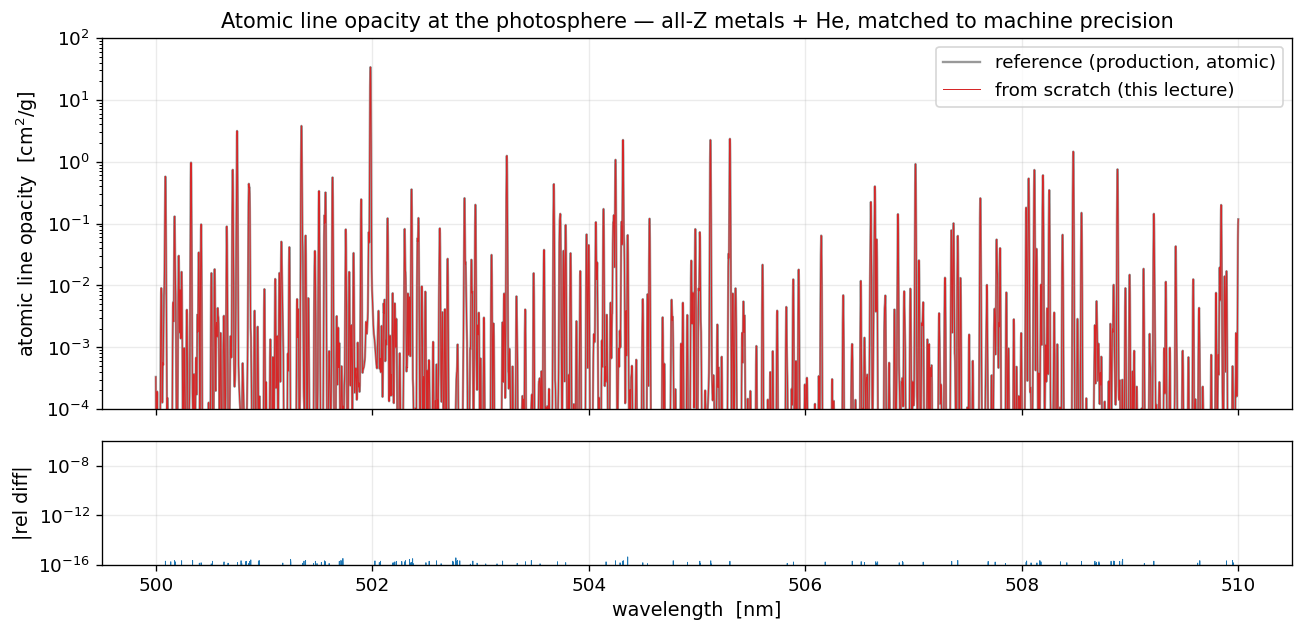

In [23]:
# a representative photospheric layer
jp = n_depths // 2
mine_p = atomic[jp]; ref_p = ref_atomic[jp]

fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(grid, ref_p, color="0.6", lw=1.4, label="reference (production, atomic)")
ax.plot(grid, mine_p, color="C3", lw=0.6, label="from scratch (this lecture)")
ax.set_yscale("log"); ax.set_ylim(1e-4, max(ref_p.max(), mine_p.max())*3)
ax.set_ylabel(r"atomic line opacity  [cm$^2$/g]"); ax.legend(loc="upper right")
ax.set_title("Atomic line opacity at the photosphere — all-Z metals + He, matched to machine precision")
rel_p = np.abs(mine_p - ref_p) / np.where(ref_p != 0, np.abs(ref_p), 1.0)
axr.semilogy(grid, np.maximum(rel_p, 1e-17), color="C0", lw=0.5)
axr.set_xlabel("wavelength  [nm]"); axr.set_ylabel("|rel diff|"); axr.set_ylim(1e-16, 1e-6)
fig.tight_layout(); plt.show()

The forest matches line for line: every transition sits at its vacuum wavelength with the right strength, summed from its own Voigt profile and its exact population. The residual panel sits at the floating-point floor across the window — the atomic line opacity is reproduced to machine precision, absolute value and all.

## The missing piece: hydrogen

We deliberately left the hydrogen lines out. They are not a small correction — in this window the wing of H$\beta$ (486 nm) reaches well into 500–510 nm and dominates the line opacity in the deep, hot layers, the smooth floor you would see under the metal forest if we plotted the full `diag['line_opacity']`. They are absent here for a physical reason. Hydrogen lines do carry the usual Doppler, natural, and resonance/self broadening, but what makes their wings *non-Voigt* — and dominant — is the **linear Stark effect**: because the hydrogen energy levels are near-degenerate, the electric field of the surrounding ions and electrons shifts them **linearly** rather than quadratically, giving broad wings whose shape is set by the plasma microfield distribution rather than by the Doppler-plus-Lorentz convolution used for the metal lines. That is a different engine entirely — the HPROF4 / HLINOP line-broadening machinery — and it earns its own lecture.

So the full line opacity is the sum of the two pieces:

$$
\kappa^{\rm line}_\lambda = \underbrace{\kappa^{\rm metal}_\lambda + \kappa^{\rm He}_\lambda}_{\text{this lecture}} \;+\; \underbrace{\kappa^{\rm H}_\lambda}_{\text{next lecture, linear Stark}}.
$$

In the next lecture we build $\kappa^{\rm H}_\lambda$ from scratch and confirm that the three pieces together reproduce the complete `diag['line_opacity']` to machine precision.

## Beyond ordinary lines: autoionizing and merged-continuum profiles

Everything so far assumed one profile shape — a Voigt, the Doppler core convolved with a Lorentz wing. That covers the overwhelming majority of the line list, and it is exactly what the **line-type code** $0$ (and the helium codes) routes a transition to. But the catalog carries two more line-type codes for transitions whose physics is *not* a plain Voigt, and the wing kernel above would build them wrong. They never fired in the 500–510 nm solar window — too weak against that continuum, or simply not present — so the lecture could omit them and still match the reference to machine precision. In a **hot star** they appear and deposit real opacity, so we close the profile repertoire here.

Two shapes, two pieces of physics:

- **Autoionizing lines (line-type code $1$).** When a bound upper level lies *above* the ionization limit, it can decay not only radiatively but by ejecting an electron — **autoionization**. That open channel broadens the level enormously and, because the bound transition interferes with the continuum of free-electron states reached at the same energy, the line is **asymmetric**: the classic **Fano profile**. SYNTHE writes it in a "shore" form — a Lorentzian whose numerator carries a linear-in-detuning asymmetry term — controlled by two constants `ashore` and `bshore` that the catalog smuggles in through the Stark and van der Waals damping slots.
- **Merged-continuum lines (line-type code $81$, and any code $>3$).** Very high members of a spectral series ($n \to \infty$ toward a series limit) crowd closer and closer until individual lines overlap and **merge into a pseudo-continuum**. Past that point a line should not be drawn as a sharp profile; SYNTHE instead lays down a flat strength that **ramps linearly to zero** between a merge wavelength $w_{\rm merge}$ and a tail wavelength $w_{\rm tail}$, fading the line smoothly into the continuum so its opacity is not double-counted. This is the same continuum-merge idea the helium taper used, now as a line type in its own right.

We will rebuild both profiles from scratch and check each against pykurucz's recorded output, **bit for bit**. The hydrogen story above is untouched; this is an extension of the *profile* repertoire, not of the line list.

### The hot-star test window and the ground truth

The two profiles are invisible in this lecture's solar window, so the benchmark uses a separate ground-truth file, `reference/linetypes.npz`, generated by driving pykurucz's own synthesis of a **hot star** ($T_{\rm eff}=12000$ K, $\log g=4.0$) over 188–670 nm — where Al I autoionizing lines and He/H merged continua genuinely clear the opacity cutoff. The file stores, per contributing (line, depth) record, the **exact inputs** the leaf routine received (the wavelength and continuum slices it read, the line center, the strength, the shore/ramp constants, the cutoff) and the **output opacity delta** pykurucz deposited. We load the inputs and recompute each delta with NumPy; the stored delta is used **only** as the comparison target — we never read it into the profile.

In [24]:
# the hot-star ground truth for the two special line types (inputs + recorded deltas)
lt_ref = np.load(REF / "linetypes.npz")
teff, logg = lt_ref["teff_logg"]                        # hot-star parameters
w0, w1, w_res = lt_ref["window"]                         # start nm, end nm, grid R

# the number of autoionizing and merged-continuum (line, depth) records
n_auto = int(lt_ref["auto_n"])
n_cont = int(lt_ref["cont_n"])

print(f"hot star : Teff={teff:.0f} K  logg={logg:.2f}   window {w0:.0f}-{w1:.0f} nm (vacuum)  R={w_res:.0f}")
print(f"records  : {n_auto} autoionizing (type 1),  {n_cont} merged-continuum (type 81)")

hot star : Teff=12000 K  logg=4.00   window 188-670 nm (vacuum)  R=100000
records  : 121 autoionizing (type 1),  165 merged-continuum (type 81)


### The autoionizing (Fano/shore) profile

For an autoionizing line the production code works in **frequency**, not Doppler-step offset. At grid wavelength $\lambda$ it forms a dimensionless detuning from the line-center frequency $\nu_0$,

$$
\varepsilon = \frac{2(\nu - \nu_0)}{\gamma}, \qquad \nu = \frac{c}{\lambda}, \quad \nu_0 = \frac{c}{\lambda_0},
$$

where $\gamma = \max(|\gamma_{\rm rad}|, 10^{-30})$ is the (very large) autoionization-broadened width. The opacity at that point is the **shore-Lorentzian**

$$
\kappa(\varepsilon) = \kappa_0\,\frac{a_{\rm shore}\,\varepsilon + b_{\rm shore}}{(\varepsilon^2 + 1)\,b_{\rm shore}},
$$

with $a_{\rm shore} = \gamma_{\rm Stark}$ and $b_{\rm shore} = \gamma_{\rm vdW}$ (floored to $10^{-30}$ if it underflows) — the two constants the catalog carries in the damping slots, *not* used as ordinary Stark/van der Waals damping here. The $a_{\rm shore}\varepsilon$ term in the numerator is the asymmetry: it makes the profile rise on one wing and dip on the other, the Fano signature, instead of the symmetric $1/(\varepsilon^2+1)$ Lorentzian. The line center ($\varepsilon=0$) reduces to $\kappa_0$, the central normalisation — not necessarily the profile's maximum, since for an asymmetric Fano shape the peak can sit slightly off center. A whole-line **gate** comes first: if $\kappa_0$ is below the local continuum times the cutoff (or non-positive) the routine deposits nothing; otherwise it lays down $\kappa_0$ at center and walks each wing outward, stopping a wing once the value drops to zero or below the local cutoff.

In [25]:
# physical constants for the frequency form (engine/opacity.py)
C_LIGHT_CM = 2.99792458e10                               # speed of light [cm/s]
NM_TO_CM   = 1.0e-7                                       # nm -> cm

def autoionizing_delta(wl, cont, slice_lo, center_index, line_wavelength,
                       kappa0, gamma_rad, gamma_stark, gamma_vdw, cutoff):
    """Fano/shore-Lorentzian opacity over a stored wavelength slice, from scratch."""
    n = wl.size
    delta = np.zeros(n, dtype=np.float64)

    # line center, as a slice-local index
    c = center_index - slice_lo

    # whole-line gate: drop the line if its center cannot clear the continuum cutoff
    if kappa0 < cont[c] * cutoff or kappa0 <= 0.0:
        return delta

    # nu_0, and the autoionization-broadened width
    freq_center = C_LIGHT_CM / (line_wavelength * NM_TO_CM)   # [Hz]
    gamma  = max(abs(gamma_rad), 1e-30)

    # the shore constants ride in the damping slots: the numerator slope, and the
    # normalisation (floored if it underflows)
    ashore = gamma_stark
    bshore = gamma_vdw if abs(gamma_vdw) >= 1e-30 else 1e-30

    # the center deposits the central strength unconditionally (past the gate)
    delta[c] += kappa0

    # walk red and blue wings together, stopping each at zero or the local cutoff
    red_active = blue_active = True
    max_steps = max(c, n - c - 1)
    for offset in range(1, max_steps + 1):
        if not (red_active or blue_active):
            break
        for active, idx in ((red_active, c + offset), (blue_active, c - offset)):
            if not active or idx < 0 or idx >= n:
                # ran off this end of the slice
                if idx < 0 or idx >= n:
                    if idx >= n: red_active = False
                    else:        blue_active = False
                continue

            # the dimensionless detuning at this grid point, then the shore-Lorentzian value
            freq  = C_LIGHT_CM / (wl[idx] * NM_TO_CM)
            eps   = 2.0 * (freq - freq_center) / gamma
            value = kappa0 * (ashore * eps + bshore) / (eps * eps + 1.0) / bshore

            # below cutoff: stop this wing
            if value <= 0.0 or value < cont[idx] * cutoff:
                if idx > c: red_active = False
                else:       blue_active = False
            else:
                delta[idx] += value
    return delta
print("autoionizing shore-Lorentzian profile ready")

autoionizing shore-Lorentzian profile ready


**Benchmark the autoionizing profile.** Each stored record gives the wavelength slice, the continuum slice, the line center, $\kappa_0$, and the three constants $\gamma_{\rm rad}, a_{\rm shore}, b_{\rm shore}$. We recompute the delta from those inputs and compare to pykurucz's recorded delta with `np.array_equal` — the strictest possible test, demanding **every bit** agrees. We tally how many of the $121$ records match exactly.

In [26]:
# recompute every autoionizing record and demand a bit-for-bit match
auto_bit = 0
auto_pts = 0
auto_wls = set()
for i in range(n_auto):
    # the global index of the slice's first point
    slice_lo = int(lt_ref[f"auto{i}_slice_lo"])

    wl   = lt_ref[f"auto{i}_wl_slice"]                    # [nm]

    # the continuum slice (sets the cutoff), and pykurucz's delta (comparison target only)
    cont = lt_ref[f"auto{i}_cont_slice"]
    ref  = lt_ref[f"auto{i}_delta_vals"]

    mine = autoionizing_delta(
        wl, cont, slice_lo,
        int(lt_ref[f"auto{i}_center_index"]), float(lt_ref[f"auto{i}_line_wavelength"]),
        float(lt_ref[f"auto{i}_kappa0"]), float(lt_ref[f"auto{i}_gamma_rad"]),
        float(lt_ref[f"auto{i}_gamma_stark"]), float(lt_ref[f"auto{i}_gamma_vdw"]),
        float(lt_ref[f"auto{i}_cutoff"]))

    # exact equality, not a tolerance
    auto_bit += int(np.array_equal(mine, ref))
    auto_pts += int(np.count_nonzero(ref))
    auto_wls.add(round(float(lt_ref[f"auto{i}_line_wavelength"]), 3))
print(f"autoionizing lines (Al I) at {sorted(auto_wls)} nm")
print(f"  bit-exact records : {auto_bit}/{n_auto}    opacity points compared: {auto_pts}")
print(f"  BIT-EXACT MATCH   : {auto_bit == n_auto}")

autoionizing lines (Al I) at [193.227, 193.646] nm
  bit-exact records : 121/121    opacity points compared: 22128
  BIT-EXACT MATCH   : True


### The merged-continuum (ramp) profile

The merged-continuum profile is geometric, not spectroscopic: there is no Voigt to evaluate, only a flat strength that fades to zero. The routine walks grid indices from the line center toward the tail and computes three global indices from the full grid: `idx_start` (the center), `idx_merge` (where the ramp begins, from $w_{\rm merge}$), and `idx_tail` (where it reaches zero, from $w_{\rm tail}$). Up to the merge point it deposits the flat strength $\kappa$; from the merge point on it scales by a **linear ramp**,

$$
\kappa(\mathrm{idx}) = \kappa\;\frac{\max(\mathrm{idx}_{\rm tail} - \mathrm{idx},\,0)}{\mathrm{idx}_{\rm tail} - \max(\mathrm{idx}_{\rm merge},\,\mathrm{idx}_{\rm start})},
$$

which is $1$ at the merge index and falls to $0$ at the tail. Points blueward of the line center are skipped, and the walk stops the moment the (ramped) value drops below the local continuum cutoff. The denominator is the ramp's width in pixels — clamped to at least $1$ so a degenerate ramp cannot divide by zero. Because those three indices come from `searchsorted` over the *full* hot-star grid, the reference stored them with each record, so we reproduce the ramp exactly without re-running the search on the truncated slice.

In [27]:
def merged_continuum_delta(wl, cont, slice_lo, line_wavelength, kappa, cutoff,
                           idx_start_g, idx_merge_g, idx_tail_g):
    """Flat strength ramping linearly to zero between the merge and tail indices."""
    n = wl.size
    delta = np.zeros(n, dtype=np.float64)

    # nothing to deposit
    if kappa <= 0.0 or idx_tail_g <= idx_start_g:
        return delta

    # ramp width in pixels (>=1), measured in GLOBAL indices as the routine does
    denom = max(idx_tail_g - max(idx_merge_g, idx_start_g), 1)

    # walk from the center to the tail, depositing the (ramped) flat strength
    for idx_g in range(idx_start_g, idx_tail_g):
        # global -> slice-local position; outside the stored slice means a pre-merge flat point
        loc = idx_g - slice_lo
        if loc < 0 or loc >= n:
            continue

        # blueward of center: skip
        if wl[loc] < line_wavelength:
            continue

        value = kappa

        # past the merge point: apply the ramp
        if idx_g >= idx_merge_g:
            value *= max(idx_tail_g - idx_g, 0) / denom

        # below cutoff: stop the walk
        if value < cont[loc] * cutoff:
            break
        delta[loc] += value
    return delta
print("merged-continuum ramp profile ready")

merged-continuum ramp profile ready


**Benchmark the merged-continuum profile.** Same protocol: read each record's inputs — the line wavelength, the flat strength $\kappa$, the cutoff, and the three global indices — recompute the ramp, and compare to pykurucz's recorded delta with `np.array_equal`. These are the He I / He II / H I (and a couple of Al I) series limits merging into their continua; we expect all $165$ records bit-exact. The H I entries here are *only* tests of this generic merged-continuum ramp line type in the hot-star diagnostic; the ordinary hydrogen Stark line-profile machinery deferred above is untouched and still belongs to the next lecture.

In [28]:
# recompute every merged-continuum record and demand a bit-for-bit match
cont_bit = 0
cont_pts = 0
cont_wls = set()
for i in range(n_cont):
    slice_lo = int(lt_ref[f"cont{i}_slice_lo"])
    wl   = lt_ref[f"cont{i}_wl_slice"]                    # [nm]

    # the continuum slice (sets the cutoff), and pykurucz's delta (comparison target only)
    cnt  = lt_ref[f"cont{i}_cont_slice"]
    ref  = lt_ref[f"cont{i}_delta_vals"]

    mine = merged_continuum_delta(
        wl, cnt, slice_lo,
        float(lt_ref[f"cont{i}_line_wavelength"]), float(lt_ref[f"cont{i}_kappa"]),
        float(lt_ref[f"cont{i}_cutoff"]),
        int(lt_ref[f"cont{i}_idx_start_g"]), int(lt_ref[f"cont{i}_idx_merge_g"]),
        int(lt_ref[f"cont{i}_idx_tail_g"]))
    cont_bit += int(np.array_equal(mine, ref))
    cont_pts += int(np.count_nonzero(ref))
    cont_wls.add(round(float(lt_ref[f"cont{i}_line_wavelength"]), 3))
print(f"merged-continuum lines (He/H/Al) at {sorted(cont_wls)} nm")
print(f"  bit-exact records : {cont_bit}/{n_cont}    opacity points compared: {cont_pts}")
print(f"  BIT-EXACT MATCH   : {cont_bit == n_cont}")

# the headline result for both special profiles
print()
print(f"BOTH special line types reproduced BIT-FOR-BIT: "
      f"{auto_bit == n_auto and cont_bit == n_cont}  "
      f"({auto_bit + cont_bit}/{n_auto + n_cont} records)")

merged-continuum lines (He/H/Al) at [205.059, 207.614, 260.046, 312.176, 342.187, 364.552, 364.702, 367.975, 569.615, 663.4] nm
  bit-exact records : 165/165    opacity points compared: 499622
  BIT-EXACT MATCH   : True

BOTH special line types reproduced BIT-FOR-BIT: True  (286/286 records)


### The two shapes, side by side

A picture makes the two profiles concrete. On the left we draw one Al I autoionizing line from its stored slice — the asymmetric shore-Lorentzian, sharply peaked at center with one wing riding higher than the other (the Fano asymmetry from the $a_{\rm shore}\varepsilon$ term). On the right we draw one He/H merged-continuum line — the flat strength that holds, then ramps linearly down to zero at the tail. Both are **computed** by the from-scratch routines above and overplotted on pykurucz's recorded delta; the curves lie on top of each other.

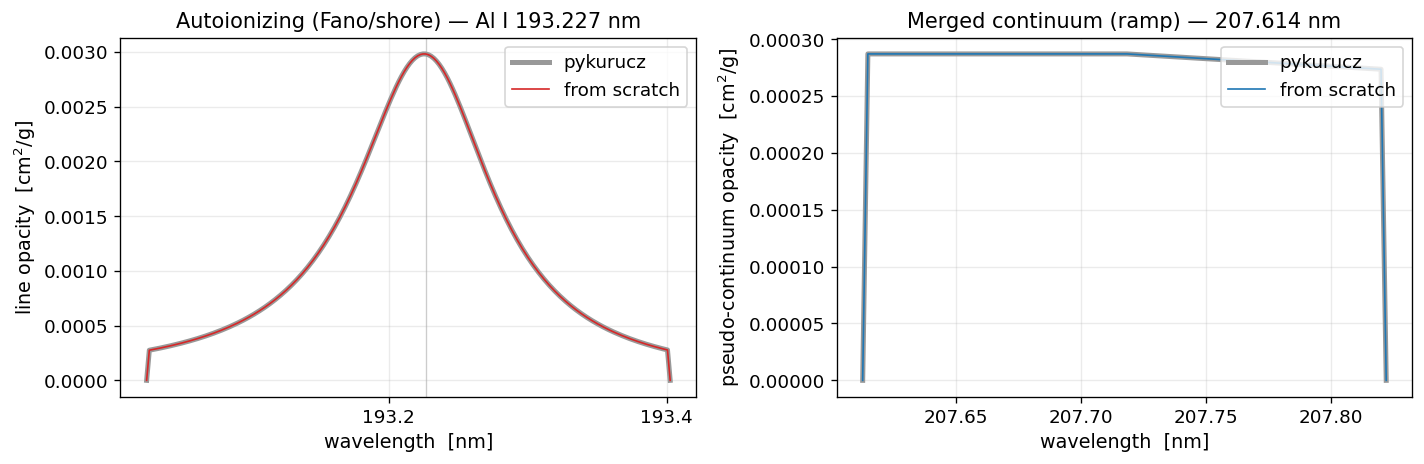

In [29]:
# pick one representative record of each type, recompute, and overlay on the reference

# an Al I autoionizing record
ai = 0
wl_a   = lt_ref[f"auto{ai}_wl_slice"]
ref_a  = lt_ref[f"auto{ai}_delta_vals"]
mine_a = autoionizing_delta(
    wl_a, lt_ref[f"auto{ai}_cont_slice"], int(lt_ref[f"auto{ai}_slice_lo"]),
    int(lt_ref[f"auto{ai}_center_index"]), float(lt_ref[f"auto{ai}_line_wavelength"]),
    float(lt_ref[f"auto{ai}_kappa0"]), float(lt_ref[f"auto{ai}_gamma_rad"]),
    float(lt_ref[f"auto{ai}_gamma_stark"]), float(lt_ref[f"auto{ai}_gamma_vdw"]),
    float(lt_ref[f"auto{ai}_cutoff"]))

# a merged-continuum record
mi = 0
wl_m   = lt_ref[f"cont{mi}_wl_slice"]
ref_m  = lt_ref[f"cont{mi}_delta_vals"]
mine_m = merged_continuum_delta(
    wl_m, lt_ref[f"cont{mi}_cont_slice"], int(lt_ref[f"cont{mi}_slice_lo"]),
    float(lt_ref[f"cont{mi}_line_wavelength"]), float(lt_ref[f"cont{mi}_kappa"]),
    float(lt_ref[f"cont{mi}_cutoff"]),
    int(lt_ref[f"cont{mi}_idx_start_g"]), int(lt_ref[f"cont{mi}_idx_merge_g"]),
    int(lt_ref[f"cont{mi}_idx_tail_g"]))

fig, (axa, axm) = plt.subplots(1, 2, figsize=(12, 4.0))
axa.plot(wl_a, ref_a, color="0.6", lw=3.0, label="pykurucz")
axa.plot(wl_a, mine_a, color="C3", lw=1.0, label="from scratch")
axa.axvline(float(lt_ref[f"auto{ai}_line_wavelength"]), color="0.8", lw=0.8, zorder=0)
axa.set_title(f"Autoionizing (Fano/shore) — Al I {lt_ref[f'auto{ai}_line_wavelength']:.3f} nm")
axa.set_xlabel("wavelength  [nm]"); axa.set_ylabel(r"line opacity  [cm$^2$/g]")
axa.locator_params(axis="x", nbins=4)                   # thin the crowded wavelength ticks
axa.legend(loc="upper right")

axm.plot(wl_m, ref_m, color="0.6", lw=3.0, label="pykurucz")
axm.plot(wl_m, mine_m, color="C0", lw=1.0, label="from scratch")
axm.set_title(f"Merged continuum (ramp) — {lt_ref[f'cont{mi}_line_wavelength']:.3f} nm")
# this ramp is a pseudo-continuum, so label the y-axis "opacity" rather than "line opacity"
axm.set_xlabel("wavelength  [nm]"); axm.set_ylabel(r"pseudo-continuum opacity  [cm$^2$/g]")
axm.locator_params(axis="x", nbins=5)
axm.legend(loc="upper right")
fig.tight_layout(); plt.show()

*(A schematic of the two physical pictures — a bound level embedded in (and interfering with) the continuum for autoionization, and a series of lines crowding into a pseudo-continuum near the limit for the merge — would complement this figure; it is a candidate for the resources folder, not generated here.)*

**What this adds.** The Voigt accumulation of this lecture handles line-type $0$ and the helium codes; these two extra profiles handle line-type $1$ (autoionizing) and $81$ (merged continuum). Both are now reproduced from scratch to the bit against pykurucz's own hot-star run. The line list is unchanged — what grew is the set of profile *shapes* a synthesis can lay down. With ordinary Voigt lines, autoionizing lines, and merged continua all in hand, the atomic profile repertoire is complete; only hydrogen's linear-Stark profile remains, and that is the next lecture.

## Synthesis: what you built and where it goes

You turned a list of numbers into an exact opacity. You read the **line list** — wavelength, `log gf`, species, excitation potential, damping, line-type code — laid down the **logarithmic wavelength grid**, formed the **exact lower-level population** ($n_{\rm ion}/U$ times the **FASTEX** Boltzmann factor), and **accumulated** the full atomic list with the production code's **Voigt wing-accumulation kernel** and its **cutoff**: every metal line from lithium to uranium plus the helium lines, reproduced to machine precision.

The lesson of this rework is precise: there was never a "calibration convention" — only a missing normalisation. Once the population is the ionic density divided by the partition function and the Boltzmann factor is the engine's own tabulated exponential, the absolute line opacity is reproduced to machine precision. Added to the continuum of Lecture 3 (and, with the hydrogen lines of the next lecture, the complete line opacity), this is the total extinction the photons face. Fed through the radiative transfer of Lectures 7–8, it produces the solar spectrum line for line.

## Summary

- A **line list** gives, per transition: wavelength, `log gf`, the species code $Z.\mathrm{ion}$, the excitation potential $\chi_\ell$, the damping constants $\gamma_{\rm rad}, \gamma_{\rm Stark}, \gamma_{\rm vdW}$, and a **line-type code** that routes it to the right kernel.
- Synthesis runs on a **logarithmic grid** of constant ratio $r$, with sampling parameter $R_{\rm grid} = 1/(r-1)$ (here $\approx 300{,}000$), and a wavelength maps to a grid index by a logarithm.
- The exact lower-level population is **`population_per_ion`** $= n_{\rm ion}/U$ (the EOS output of Lecture 2) times the **FASTEX** tabulated Boltzmann factor $e^{-\chi_\ell hc/kT}$ — getting this normalisation right is what removes the old offset.
- The line-amplitude is $\kappa_0 = c_{gf}\,(n_{\rm ion}/U)/(\rho\,v_D/c)\,e^{-\chi_\ell hc/kT}$ (the TRANSP normalisation, not the physical center value, which also carries $H(a,0)$); a **cutoff** ($\kappa_0 < 10^{-3}\kappa^{\rm cont}$) drops negligible lines; the **wing kernel** walks outward from center and stops at the cutoff.
- The full atomic line opacity ($\kappa^{\rm metal} + \kappa^{\rm He}$, all $Z = 3$–$92$ plus He) reproduces the reference to **machine precision** — median relative error exactly zero, max at the floating-point floor where the atomic term dominates.
- **Hydrogen** is held back: its wings are dominated by the **linear Stark effect** (non-Voigt) and built in the next lecture; $\kappa^{\rm line} = \kappa^{\rm metal} + \kappa^{\rm He} + \kappa^{\rm H}$.

## Practice exercises

**1. What the cutoff costs.** Lower `CUTOFF` to $10^{-4}$ and raise it to $10^{-2}$, re-run the metal loop, and count how many lines survive (`kept`) and how the total opacity changes. Where in the profile (core or wing) does the cutoff bite, and what does that imply for weak-line blends?

**2. The heavy tail.** Re-run the metal accumulation with the $Z > 30$ lines excluded (add `& (Zc <= 30)` to `line_ok`) and compare to the full result. By how much, and at which wavelengths, do the 754 neutron-capture lines change the opacity? Why does reproducing the reference to machine precision require every one of them?

**3. FASTEX vs exp.** Replace `fast_ex` with a plain `np.exp(-x)` in the Boltzmann factor and re-run the benchmark. Where does the agreement break, and at what level? This is a clean demonstration that matching the production code means matching its *tables*, not just its formulas.

**4. Excitation and depth.** Split the metal list into low- ($\chi_\ell < 1\ \mathrm{eV}$) and high-excitation ($\chi_\ell > 3\ \mathrm{eV}$) lines and accumulate each separately at a shallow and a deep layer. Which set dominates where, and why does that make high-excitation lines better temperature diagnostics?

## Further reading

- **Kurucz, R. L. (2011). *Including all the lines*, Canadian Journal of Physics, 89, 417.** The philosophy and construction of the line lists this lecture reads — and the argument for keeping every weak line.
- **Harris, D. L. (1948). *On the line-absorption coefficient due to Doppler effect and damping*, ApJ, 108, 112.** The Voigt-function polynomial tables `h0tab/h1tab/h2tab` the accumulation evaluates.
- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed.** Chapters 11–13 on line absorption and the assembly of many lines.
- **Anstee, S. D. & O'Mara, B. J. (1995). *Width cross-sections...*, MNRAS, 276, 859.** The modern van der Waals broadening behind the $\gamma_{\rm vdW}$ damping constant.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference line opacity is computed with.